# Hypothesis Testing with Men's and Women's Soccer Matches

![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

In [2]:
# Importing 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

women = pd.read_csv('women_results.csv')
men = pd.read_csv('men_results.csv')

## Exploratory data analysis

In [3]:
women.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4884 non-null   int64 
 1   date        4884 non-null   object
 2   home_team   4884 non-null   object
 3   away_team   4884 non-null   object
 4   home_score  4884 non-null   int64 
 5   away_score  4884 non-null   int64 
 6   tournament  4884 non-null   object
dtypes: int64(3), object(4)
memory usage: 267.2+ KB


In [4]:
men.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44353 entries, 0 to 44352
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  44353 non-null  int64 
 1   date        44353 non-null  object
 2   home_team   44353 non-null  object
 3   away_team   44353 non-null  object
 4   home_score  44353 non-null  int64 
 5   away_score  44353 non-null  int64 
 6   tournament  44353 non-null  object
dtypes: int64(3), object(4)
memory usage: 2.4+ MB


In [5]:
print(women.value_counts())
print(men.value_counts())

Unnamed: 0  date        home_team      away_team            home_score  away_score  tournament             
0           1969-11-01  Italy          France               1           0           Euro                       1
3254        2014-03-12  North Korea    United States        0           3           Algarve Cup                1
3261        2014-03-12  Canada         Republic of Ireland  2           1           Cyprus Cup                 1
3260        2014-03-12  Italy          Australia            2           5           Cyprus Cup                 1
3259        2014-03-12  Netherlands    Switzerland          4           1           Cyprus Cup                 1
                                                                                                              ..
1626        2003-09-28  United States  North Korea          3           0           FIFA World Cup             1
1625        2003-09-28  Sweden         Nigeria              3           0           FIFA World Cup   

## Filtering the data
Filtering the data to only include official `FIFA World Cup` matches that took place after `2002-01-01`.

In [6]:
Fifa_Women = women[women['tournament'] == 'FIFA World Cup']
Fifa_Men = men[men['tournament'] == 'FIFA World Cup']

Filtering for matches after 2002-01-01

In [7]:
Fifa_Women['date'] = pd.to_datetime(Fifa_Women['date'])
Fifa_Men['date'] = pd.to_datetime(Fifa_Men['date'])

Fifa_Women_toDate = Fifa_Women[Fifa_Women['date'] > '2002-01-01']
Fifa_Men_toDate = Fifa_Men[Fifa_Men['date'] > '2002-01-01']

C:\Users\cresp\AppData\Local\Temp\ipykernel_13068\242227906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fifa_Women['date'] = pd.to_datetime(Fifa_Women['date'])
C:\Users\cresp\AppData\Local\Temp\ipykernel_13068\242227906.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Fifa_Men['date'] = pd.to_datetime(Fifa_Men['date'])


## Choosing the correct hypothesis test
Using EDA to determine the appropriate hypothesis test for this dataset and scenario.
- Because there are two independent groups, men's and women's, this scenario requires an unpaired two-sample test.
- An unpaired t-test and a Wilcoxon-Mann-Whitney test are the two most commmon two-sample tests, where the Wilcoxon-Mann-Whitney test is a non-parametric version of the unpaired t-test.
- To determine if a parametric or non-parametric test is appropriate, I'll need to verify the underlying assumptions of parametric tests, including checking the sample size in each group and the normality of each distribution.

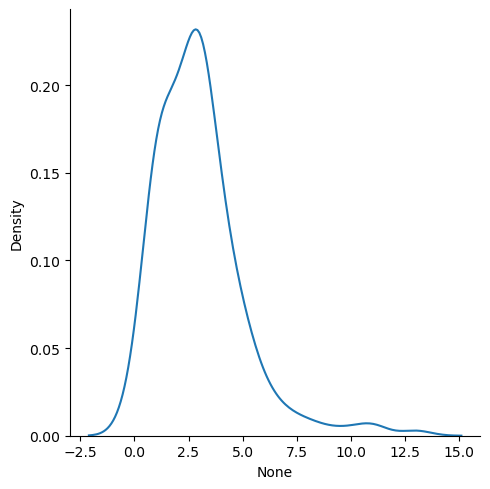

In [8]:
# Visualizing the data distributions 
sns.displot(data=Fifa_Women_toDate,
           x=Fifa_Women_toDate['home_score'] + Fifa_Women_toDate['away_score'],
           kind='kde')

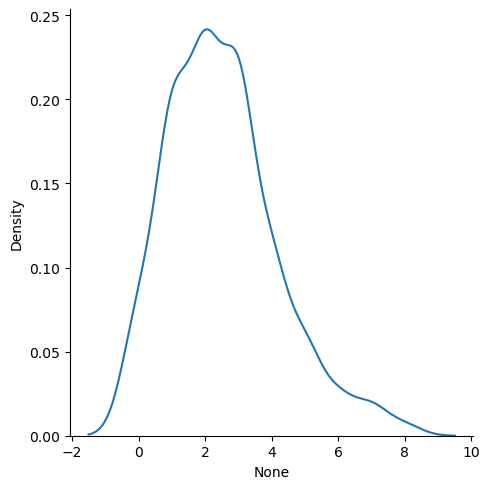

In [9]:
# Visualizing the data distributions 
sns.displot(data=Fifa_Men_toDate,
           x=Fifa_Men_toDate['home_score'] + Fifa_Men_toDate['away_score'],
           kind='kde')

It looks like they don't follow a normal distribution, so let's head on to normality test just to be sure.

In [10]:
# Understanding the sample size of the DataFrames 
print(Fifa_Women_toDate.shape[0])
print(Fifa_Men_toDate.shape[0])

200
384


Since the sample is too small we can do a Shapiro-Wilk Test

In [11]:
# Checking sample sizes
from scipy.stats import shapiro

# Compute total scores for both datasets
women_scores = (Fifa_Women_toDate['home_score'] + Fifa_Women_toDate['away_score']).dropna()
men_scores = (Fifa_Men_toDate['home_score'] + Fifa_Men_toDate['away_score']).dropna()

# Shapiro-Wilk test for Women's scores
stat_women, p_women = shapiro(women_scores)
print(f"Women's Scores - Shapiro-Wilk Test: Stat={stat_women}, P-value={p_women}")

# Shapiro-Wilk test for Men's scores
stat_men, p_men = shapiro(men_scores)
print(f"Men's Scores - Shapiro-Wilk Test: Stat={stat_men}, P-value={p_men}")

# Interpretation
alpha = 0.05  # Significance level
if p_women < alpha:
    print("Women's scores do NOT follow a normal distribution (reject H₀).")
else:
    print("Women's scores MAY follow a normal distribution (fail to reject H₀).")

if p_men < alpha:
    print("Men's scores do NOT follow a normal distribution (reject H₀).")
else:
    print("Men's scores MAY follow a normal distribution (fail to reject H₀).")


Women's Scores - Shapiro-Wilk Test: Stat=0.8491013050079346, P-value=3.8905201759850683e-13
Men's Scores - Shapiro-Wilk Test: Stat=0.9266489744186401, P-value=8.894154401688226e-13
Women's scores do NOT follow a normal distribution (reject H₀).
Men's scores do NOT follow a normal distribution (reject H₀).


The data **is not normally distributed**, the best approach is to proceed with a Wilcoxon-Mann-Whitney test

## Performing the hypothesis test

In [12]:
from scipy.stats import mannwhitneyu

# Ensuring numeric and drop NaNs
women_scores = (Fifa_Women_toDate['home_score'] + Fifa_Women_toDate['away_score']).dropna()
men_scores = (Fifa_Men_toDate['home_score'] + Fifa_Men_toDate['away_score']).dropna()

# Performing Mann-Whitney U Test
stat, p_val = mannwhitneyu(women_scores, men_scores, alternative='greater')

# Output the result
print(f"Mann-Whitney U Test: Stat={stat}, P-value={p_val}")

# Interpretation
alpha = 0.10  # Significance level of 10%
if p_val < alpha:
    #
    print("Reject H₀: There is a significant difference in the mean number of goals.")
    result = "reject"
else:
    #
    print("Fail to Reject H₀: No significant difference in the mean number of goals.")
    result = "fail to reject"

# Store the p-value and result in a dictionary
result_dict = {"p_val": p_val, "result": result}

# Output the result dictionary
print(result_dict)


Mann-Whitney U Test: Stat=43273.0, P-value=0.005106609825443641
Reject H₀: There is a significant difference in the mean number of goals.
{'p_val': 0.005106609825443641, 'result': 'reject'}
